In [1]:
from scipy.special import gammaln
import matplotlib.pyplot as plt
import numpy as np

In [24]:
import matplotlib

cmap = matplotlib.colormaps['cool']


In [3]:
class bayes_factor_node():
    def __init__(self):
        self.max_depth_node = False
        self.data_truncated_node = False
        self.left_child = None
        self.right_child = None
        self.value = None
    def set_value(self, value):
        self.value = value
    def set_children(self, left_child, right_child):
        self.left_child = left_child
        self.right_child = right_child
    def flag_max_depth(self):
        self.max_depth_node = True
    def flag_data_truncation(self):
        self.data_truncated_node = True
    def sum_value(self, depth, min_depth = 1):
        if depth < 1 : return 0
        left_value = self.left_child.sum_value(depth-1, min_depth) if self.left_child is not None else 0
        right_value = self.right_child.sum_value(depth-1, min_depth) if self.right_child is not None else 0
        value = self.value if self.value is not None and depth >= min_depth else 0
        return value/ 2.302585092994046 + left_value + right_value



def get_bayes_factor(data_1, data_2, c = 5, max_depth=6, aj=lambda depth: depth**2, log_BF=False, get_tree = False):
    """
    nonparamteric Bayes factors

    parameters:

    data_1 : arraylike
        Numpy array of data points sampled from the first distribution
    data_2 : arraylike
        Numpy array of data points sampled from the second distribution
    c : int 
        The tunable paramter c descibed in https://arxiv.org/abs/0910.5060v3
    max_depth : int
        The maximum depth of the partially specified Polya tree as described in https://arxiv.org/abs/0910.5060v3
        The Polya tree has a tree height of max_depth.
    aj : function
        The prescription for calculateing aj terms as a function of tree depth 
        as described in https://arxiv.org/abs/0910.5060v3
    log_BF: bool
        When False, the Bayes factor is returned, and when True, log10(Bayes factor) is returned
    get_tree: bool
        If True, the tree containing the full Poly Tree parition is raturned rather than a single value
    """

    data_switch = len(data_1)
    combined_data = np.concatenate([data_1, data_2])
    del data_1, data_2

    # partition the data into quartiles
    quantiles = np.quantile(combined_data, np.linspace(0,1,2**max_depth + 1))

    # get the log bayes factor
    tree = bayes_factor_node() if get_tree else None
    logbf = _get_bayes_factor(combined_data, data_switch, quantiles, low=0, high=1, c=c, depth=1, max_depth=max_depth, aj=aj, tree=tree)
    if get_tree:
        return tree
    
    # return either the bayes factor or log bayes factor
    if log_BF:
        log10bf = logbf / 2.302585092994046 # np.log(10) = 2.302585092994046
        return log10bf
    else:
        bf = np.exp(logbf)
        return bf

def _get_bayes_factor(combined_data, data_switch, quantiles, low, high, c, depth, max_depth,aj, tree = None):
    """
    helper function called by get_bayes_factor

    parameters:

    combined_data : arraylike
        Numpy array of data points sampled from the first and second distributions. 
        Data from the second distribution hould follow after data from the first
    data_switch : int
        The array index seperating the two sampled distributions in combined_data
    low : float
        The low quantile for the current Polya tree node
    high : float
        The high quantile for the current Polya tree node
    c : int 
        The tunable paramter c descibed in https://arxiv.org/abs/0910.5060v3
    depth : int
        The depth of the current node in the Polya tree
    max_depth : int
        The maximum depth of the partially specified Polya tree as described in https://arxiv.org/abs/0910.5060v3
    aj : function
        The prescription for calculateing aj terms as a function of tree depth 
        as described in https://arxiv.org/abs/0910.5060v3
    tree : bayes_factor_node or None
        The (optional) tree used for saving the Bayes factor calculation in each partition
    
    """
    
    if depth > max_depth: 
        if tree is not None:
            tree.flag_max_depth()
            return
        return 0

    # select quartiles
    low_q = quantiles[int((2**max_depth ) * low)]
    mid_q = quantiles[int((2**max_depth ) * (low+high)/2)]
    high_q = quantiles[int((2**max_depth ) * high)]

    # count data in quartiles
    if high == 1:
        data_1_low = np.count_nonzero((combined_data[:data_switch]>=low_q)*(combined_data[:data_switch]<=mid_q))
        data_2_low = np.count_nonzero((combined_data[data_switch:]>=low_q)*(combined_data[data_switch:]<=mid_q))
        data_1_high = np.count_nonzero((combined_data[:data_switch]>=mid_q)*(combined_data[:data_switch]<=high_q))
        data_2_high = np.count_nonzero((combined_data[data_switch:]>=mid_q)*(combined_data[data_switch:]<=high_q))
    else:
        data_1_low = np.count_nonzero((combined_data[:data_switch]>=low_q)*(combined_data[:data_switch]<mid_q))
        data_2_low = np.count_nonzero((combined_data[data_switch:]>=low_q)*(combined_data[data_switch:]<mid_q))
        data_1_high = np.count_nonzero((combined_data[:data_switch]>=mid_q)*(combined_data[:data_switch]<high_q))
        data_2_high = np.count_nonzero((combined_data[data_switch:]>=mid_q)*(combined_data[data_switch:]<high_q))

    # calculate the n_j terms for the current binnings
    data_1_n_j = [data_1_low, data_1_high]
    data_2_n_j = [data_2_low, data_2_high]

    # truncate the tree where there is no data
    if np.sum(data_1_n_j) == 0 or np.sum(data_2_n_j) == 0:
        if tree is not None:
            tree.set_value(0)
            tree.nj = (0,0)
            tree.flag_data_truncation()
            return
        return 0

    if tree is not None:
        left_tree = bayes_factor_node()
        right_tree = bayes_factor_node()
        tree.nj=(data_1_n_j, data_2_n_j)
        tree.set_children(left_tree, right_tree)
    else:
        left_tree = None
        right_tree = None

    # calculate the a_j term for the current tree depth
    a_j = c * aj(depth)

    # calculate b_j

    log_gamma_summand_1 = 2 * gammaln(a_j) - gammaln(2 * a_j)
    log_gamma_summand_2 = gammaln(a_j + data_1_n_j[0] + data_2_n_j[0]) + gammaln(a_j + data_1_n_j[1] + data_2_n_j[1]) 
    log_gamma_summand_3 = - gammaln(2*a_j + data_1_n_j[0] + data_2_n_j[0] + data_1_n_j[1] + data_2_n_j[1])
    log_gamma_summand_4 = gammaln(2*a_j + data_1_n_j[0] + data_1_n_j[1]) + gammaln(2*a_j + data_2_n_j[0] + data_2_n_j[1])
    log_gamma_summand_5 = - gammaln(a_j + data_1_n_j[0]) - gammaln(a_j + data_2_n_j[0]) - gammaln(a_j + data_1_n_j[1]) - gammaln(a_j + data_2_n_j[1])

    log_b_j = log_gamma_summand_1 + log_gamma_summand_2 + log_gamma_summand_3 + log_gamma_summand_4 + log_gamma_summand_5

    # calculate the product of b_j terms on the left partition of the tree
    log_left_tree_b_j = _get_bayes_factor(combined_data, data_switch, quantiles, low, (low+high)/2, c, depth+1, max_depth, aj, left_tree)

    # calculate the product of b_j terms on the right partition of the tree
    log_right_tree_b_j = _get_bayes_factor(combined_data, data_switch, quantiles, (low+high)/2, high, c, depth+1, max_depth, aj, right_tree)

    if tree is not None:
        tree.set_value(log_b_j)
        return
    # calculate the product of the b_j terms
    summed_b_j = log_b_j + log_left_tree_b_j + log_right_tree_b_j

    return summed_b_j


# Examples of population comparisons

In [21]:
np.random.seed(0)
population_1 = np.random.normal(size=50)
population_2 = np.random.normal(size=50, loc=1)

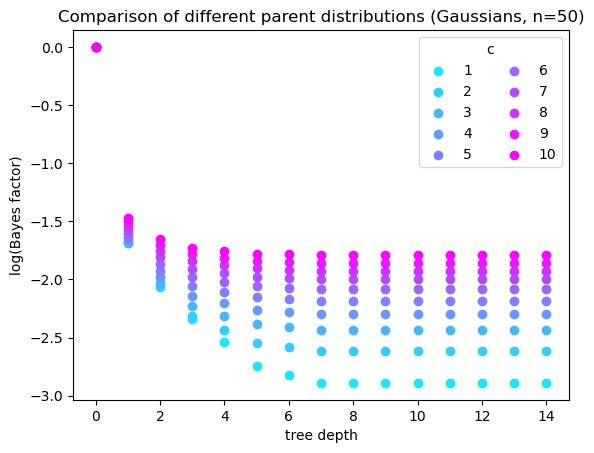

In [29]:
max_c = 10
max_depth = 15

for c in range (1, max_c+1):
    
    rgba = cmap(c/max_c)
    
    tmp = get_bayes_factor(
            population_1,
            population_2,
            c=c,
            max_depth=max_depth,
            log_BF=True,
            get_tree = True
        )
    
    plt.scatter(np.arange(max_depth), [tmp.sum_value(i) for i in range(max_depth)], color = rgba,label=c)

plt.legend(title='c',ncols=2)
plt.xlabel('tree depth')
plt.ylabel('log(Bayes factor)')
plt.title('Comparison of different parent distributions (Gaussians, n=50)');

In [16]:
np.random.seed(0)
population_1 = np.random.normal(size=100)
population_2 = np.random.normal(size=100)

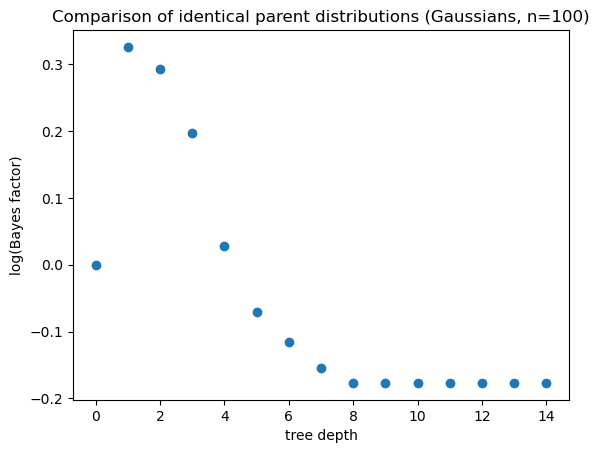

In [17]:
max_depth = 15
tmp = get_bayes_factor(
        population_1,
        population_2,
        c=5,
        max_depth=max_depth,
        log_BF=True,
        get_tree = True
    )
plt.scatter(np.arange(max_depth), [tmp.sum_value(i) for i in range(max_depth)])
plt.xlabel('tree depth')
plt.ylabel('log(Bayes factor)')
plt.title('Comparison of identical parent distributions (Gaussians, n=100)');

In [18]:
np.random.seed(0)
population_1 = np.random.normal(size=10000)
population_2 = np.random.normal(size=10000)

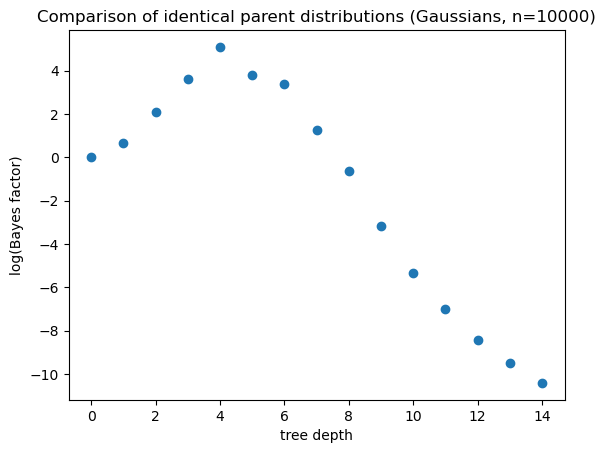

In [19]:
max_depth = 15
tmp = get_bayes_factor(
        population_1,
        population_2,
        c=5,
        max_depth=max_depth,
        log_BF=True,
        get_tree = True
    )
plt.scatter(np.arange(max_depth), [tmp.sum_value(i) for i in range(max_depth)])
plt.xlabel('tree depth')
plt.ylabel('log(Bayes factor)')
plt.title('Comparison of identical parent distributions (Gaussians, n=10000)');

# DR2 galaxy counts

There are 1,420,580 void galaxies and 3,197,830 wall galaxies in the main sample, 

There are 7464 void galaxies and 8641 wall galaxies in the metallicity sample

Task #1: Create a toy model for the main sample that has two gaussian populations drawn from the same parent distribution, where the number of points in each distribution matched the void and wall counts. Create plots that vary the value of c between 1 and 10 and vary the tree depth from 0 to 15. If you find that the bayes factors stay greater than -2 for all tree depth values, try increasing hte tree depth further unitl you dind where the algorithms overfits the data (bayes factors signifignatly less than -2). Take caution that large tree depth values (~20) may incur proibitively long runtimes, so stop if you find that the calcaultion is impractical.

Task #2: Repeat the steps of Task #1 but for the metallicity sample. The sample size is smaller, so the code should run faster.

Task #3: Create a toy model for the main sample where the gaussians are offset by some displacement value D. Assume a fixed value of c and the tree depth (discuss results of previous tasks with the group first) and then plot the variation of the Bayes factors with respect to D.

Task #4: Repeat Task #3 for the matallicity sample